## CHURN ANALYSIS

In [1]:
import pandas as pd
import numpy as np

pd.set_option('display.max_columns', None)

In [2]:
df = pd.read_csv(r"C:\Users\krn95\OneDrive\Desktop\Project\NEW PYTHON PROJECT\archive\WA_Fn-UseC_-Telco-Customer-Churn.csv")

In [3]:
print("Rows and Columns : ", df.shape)

Rows and Columns :  (7043, 21)


In [4]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [5]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [7]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [8]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors = 'coerce')

In [9]:
df['TotalCharges'].isnull().sum()

11

In [10]:
df[df['TotalCharges'].isnull()][['customerID', 'tenure', 'MonthlyCharges']]

,customerID,tenure,MonthlyCharges
488,4472-LVYGI,0,52.55
753,3115-CZMZD,0,20.25
936,5709-LVOEQ,0,80.85
1082,4367-NUYAO,0,25.75
1340,1371-DWPAZ,0,56.05
3331,7644-OMVMY,0,19.85
3826,3213-VVOLG,0,25.35
4380,2520-SGTTA,0,20.00
5218,2923-ARZLG,0,19.70
6670,4075-WKNIU,0,73.35


In [11]:
df = df.dropna(subset=['TotalCharges'])

In [12]:
df.shape

(7032, 21)

In [13]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [14]:
print("Number of Duplicates items : ",df.duplicated().sum())

Number of Duplicates items :  0


In [15]:
df['customerID'].duplicated().sum()

0

In [16]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7032.000000,7032.000000,7032.000000,7032.000000
mean,0.162400,32.421786,64.798208,2283.300441
std,0.368844,24.545260,30.085974,2266.771362
min,0.000000,1.000000,18.250000,18.800000
25%,0.000000,9.000000,35.587500,401.450000
50%,0.000000,29.000000,70.350000,1397.475000
75%,0.000000,55.000000,89.862500,3794.737500
max,1.000000,72.000000,118.750000,8684.800000


In [17]:
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
distribution_summary = pd.DataFrame({
    'Skewness' : df[num_cols].skew(),
    'Kurtosis' : df[num_cols].kurtosis()})

distribution_summary

,Skewness,Kurtosis
tenure,0.237731,-1.387823
MonthlyCharges,-0.222103,-1.256156
TotalCharges,0.961642,-0.231799


In [18]:
for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 = 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower) | (df[col] > upper)]

print(f"\n{col}")
print(f"Outliers : {len(outliers)}")


TotalCharges
Outliers : 5942


C:\Users\krn95\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


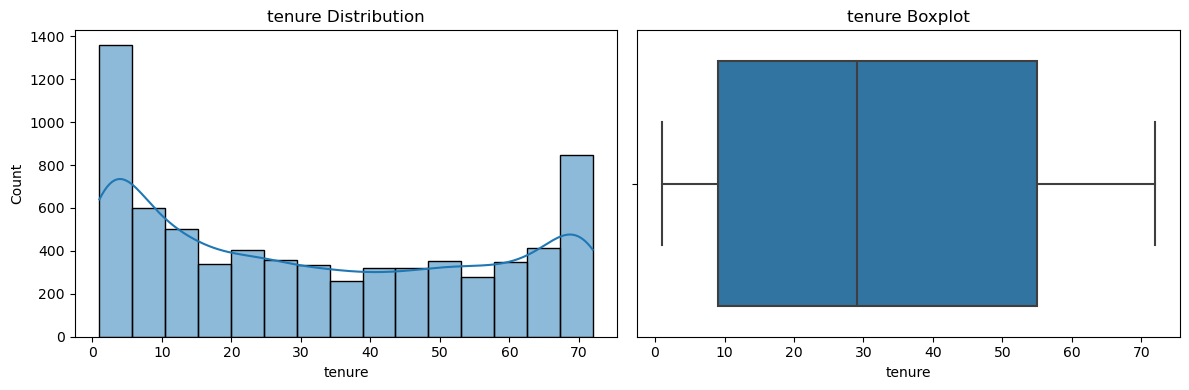

C:\Users\krn95\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


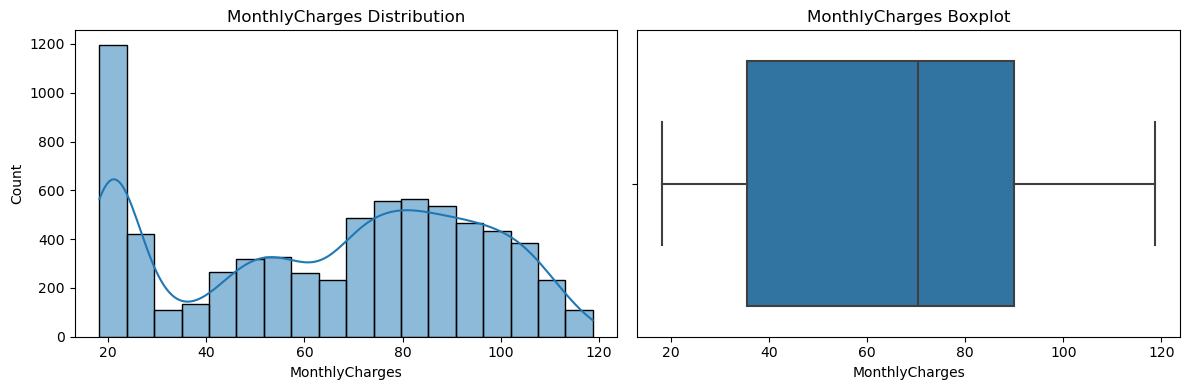

C:\Users\krn95\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


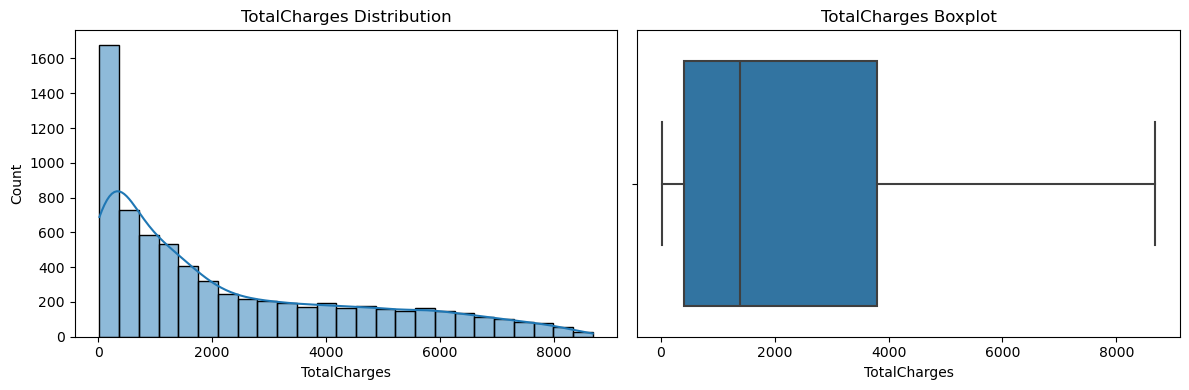

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns
for col in num_cols:
    fig, axes = plt.subplots(1, 2, figsize=(12,4))

    sns.histplot(data=df, x=col, kde=True, ax=axes[0])
    axes[0].set_title(f'{col} Distribution')

    sns.boxplot(x=df[col], ax=axes[1])
    axes[1].set_title(f'{col} Boxplot')

    plt.tight_layout()
    plt.show()

In [20]:
df[df['TotalCharges'] > 5942][
    ['customerID','tenure','MonthlyCharges','TotalCharges','Churn']
].head(20)

,customerID,tenure,MonthlyCharges,TotalCharges,Churn
15,3655-SNQYZ,69,113.25,7895.15,No
17,9959-WOFKT,71,106.70,7382.25,No
28,5248-YGIJN,72,90.25,6369.45,No
30,3841-NFECX,71,96.35,6766.95,No
35,6234-RAAPL,72,99.90,7251.70,No
56,8769-KKTPH,63,99.65,6311.20,No
57,5067-XJQFU,66,108.45,7076.35,No
59,5954-BDFSG,72,107.50,7853.70,No
72,1891-QRQSA,64,111.60,7099.00,No
75,2673-CXQEU,56,110.50,6139.50,No


In [21]:
df[['tenure','MonthlyCharges','TotalCharges']].corr()

,tenure,MonthlyCharges,TotalCharges
tenure,1.000000,0.246862,0.825880
MonthlyCharges,0.246862,1.000000,0.651065
TotalCharges,0.825880,0.651065,1.000000


## EDA Section

## EDA 1 : Overall Churn Rate

**What percentage of customers are leaving?**

In [22]:
print("Churn Counts : ", df['Churn'].value_counts())
print("Churn Percentage : ", round(df['Churn'].value_counts(normalize=True)*100, 2))

Churn Counts :  Churn
No     5163
Yes    1869
Name: count, dtype: int64
Churn Percentage :  Churn
No     73.42
Yes    26.58
Name: proportion, dtype: float64


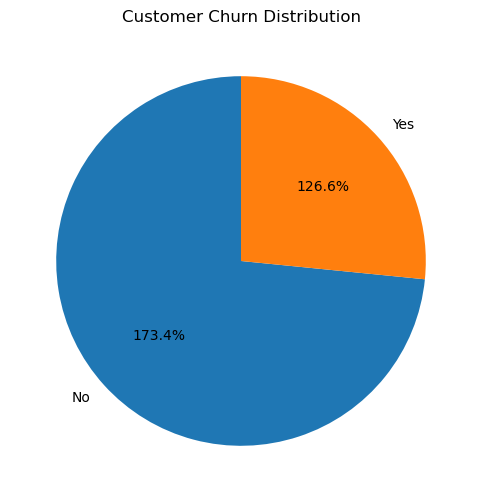

In [23]:
churn_counts = df['Churn'].value_counts()

plt.figure(figsize=(6,6))

plt.pie(churn_counts, labels=churn_counts.index, autopct='1%.1f%%', startangle=90)

plt.title('Customer Churn Distribution')
plt.show()

**EDA 1 : Insight**

Out of 7032 customers, 1869 custmoers have churned, resulting in a churn rate of 26.58%. This means approximately one out of every four customers leaves the company, indicating a significant customer retention challenge. Reducing churn could have a substantial impact on revenue and profitability.

## EDA 2 : Contract Type vs Churn

**Which contract type experiences the highest churn?**

In [24]:
# Churn percentage by Contract

contract_churn = pd.crosstab(df['Contract'], df['Churn'], normalize='index') * 100
contract_churn.round(2)

Churn,No,Yes
Contract,,
Month-to-month,57.29,42.71
One year,88.72,11.28
Two year,97.15,2.85


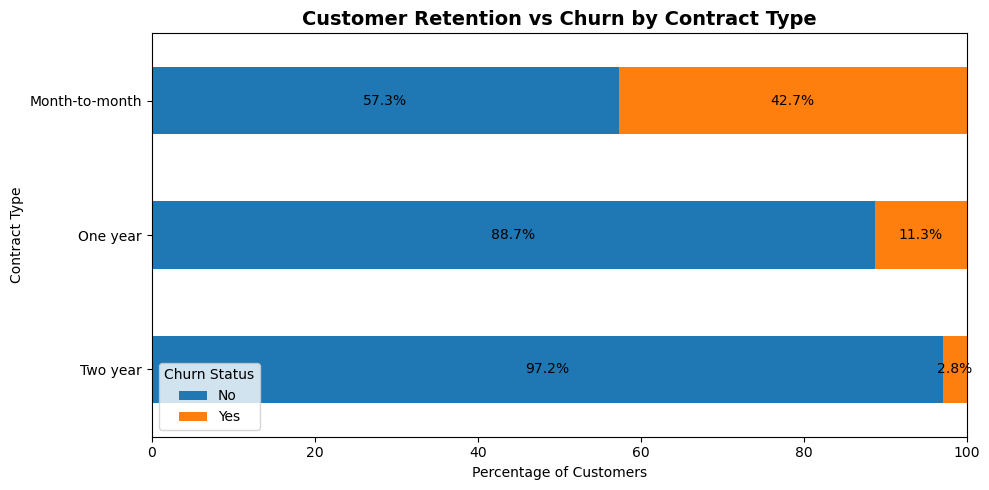

In [25]:
contract_churn = contract_churn.sort_values('Yes')

ax = contract_churn.plot(kind ='barh', stacked=True, figsize=(10,5))

for container in ax.containers:
    ax.bar_label(container, fmt='%1.1f%%', label_type='center', fontsize=10)

plt.title('Customer Retention vs Churn by Contract Type', fontsize=14, fontweight='bold')
plt.xlabel('Percentage of Customers')
plt.ylabel('Contract Type')
plt.legend(title='Churn Status', loc='lower left')
plt.xlim(0, 100)

plt.tight_layout()
plt.show()

**EDA 2 : Insight** 

Customers on month-to-month contracts exhibit the highest churn rate (42.71%), whereas customers on two-year contracts show the lowest churn rate (2.85%). This indicates that longer contract commitments significantly improve customer retention. The company should consider offering incentives to encourage customers to switch from month-to-month plans to annual contracts.

## EDA 3 : Payment Method vs Churn

**Which Payment method is associated with the highest customer churn?**

In [26]:
payment_churn = pd.crosstab(df['PaymentMethod'], df['Churn'], normalize='index') * 100
payment_churn.round(2)

Churn,No,Yes
PaymentMethod,,
Bank transfer (automatic),83.27,16.73
Credit card (automatic),84.75,15.25
Electronic check,54.71,45.29
Mailed check,80.80,19.20


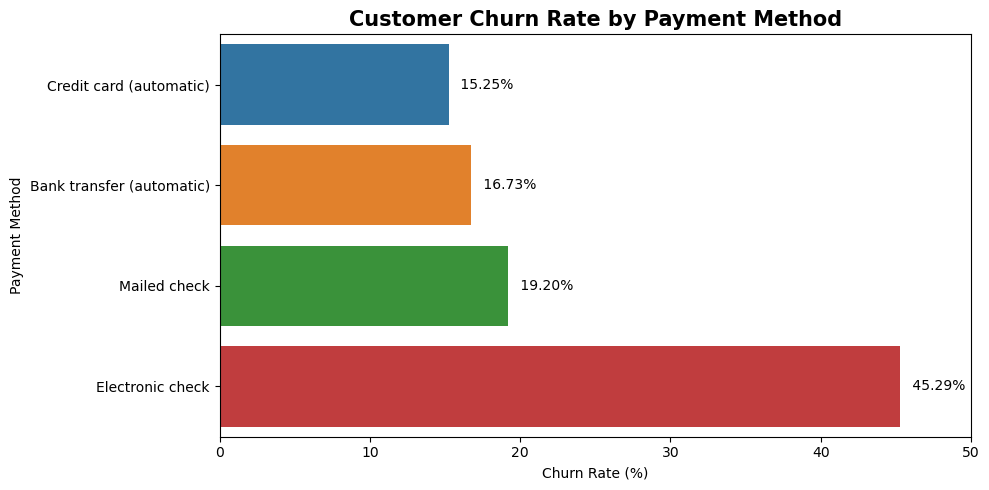

In [27]:
payment_churn_rate = payment_churn['Yes'].sort_values()

plt.figure(figsize=(10,5))

ax = sns.barplot(x=payment_churn_rate.values, y=payment_churn_rate.index)

for i, v in enumerate(payment_churn_rate.values):
    ax.text(v + 0.5, i, f'{v: .2f}%', va='center')

plt.title('Customer Churn Rate by Payment Method', fontsize=15, fontweight='bold')
plt.xlabel('Churn Rate (%)')
plt.ylabel('Payment Method')
plt.xlim(0, 50)

plt.tight_layout()
plt.show()

**EDA 3 : Insight**

Customers using Electronic Check ehibit the highest churn rate (45.29%, substantially exceeding all other payment methods. Customers enrolled in automatic payment methods such as Credit Card and Bank Transfer show significantly lower churn rates. This suggests that payment convenience and customer engagement may influence retention. Encouraging customers to switch to automatic payment option would help reduce churn.

## EDA 4 : Tenure vs Churn

**Are new customers more likely to leave than long-term customers?**

In [28]:
df.groupby('Churn')['tenure'].describe().round(2)

,count,mean,std,min,25%,50%,75%,max
Churn,,,,,,,,
No,5163.0,37.65,24.08,1.0,15.0,38.0,61.0,72.0
Yes,1869.0,17.98,19.53,1.0,2.0,10.0,29.0,72.0


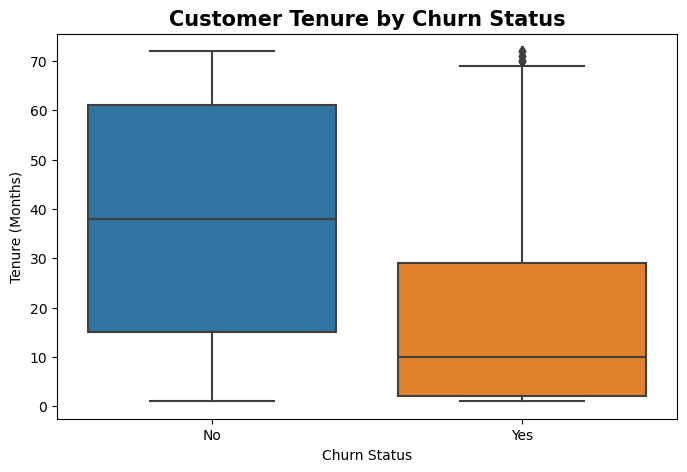

In [29]:
plt.figure(figsize=(8,5))

sns.boxplot(data=df, x='Churn', y='tenure')

plt.title('Customer Tenure by Churn Status', fontsize=15, fontweight='bold')
plt.xlabel('Churn Status')
plt.ylabel('Tenure (Months)')
plt.show()

**EDA 4 : Insight**

Customers who churned had a median tenure of only 10 months compared to 38 months for retained customers. This suggests that churn risk is highest during the early stages of the customer lifecycle. Strengthening onboarding programs, customer engagement initiatives and first-year retention strategies could significantly reduce customer attrition.

## EDA 5 : Monthly Charges vs Churn

**Are customers with higher monthly charges more likely to churn?**

In [30]:
df.groupby('Churn')['MonthlyCharges'].describe().round(2)

,count,mean,std,min,25%,50%,75%,max
Churn,,,,,,,,
No,5163.0,61.31,31.09,18.25,25.10,64.45,88.48,118.75
Yes,1869.0,74.44,24.67,18.85,56.15,79.65,94.20,118.35


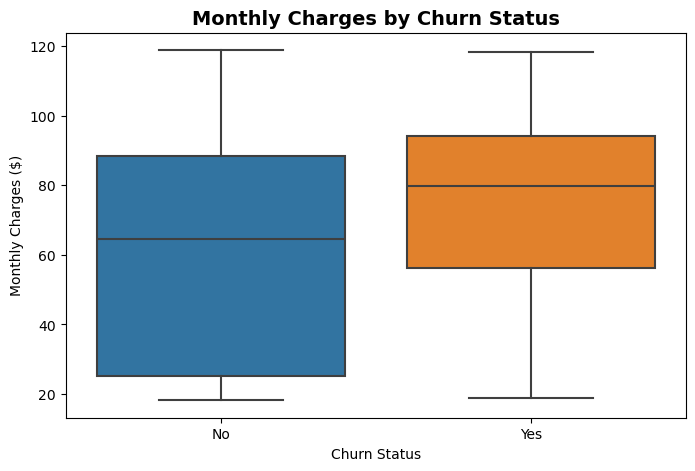

In [31]:
plt.figure(figsize=(8,5))

sns.boxplot(data=df, x='Churn', y='MonthlyCharges')
plt.title('Monthly Charges by Churn Status', fontsize=14, fontweight='bold')

plt.xlabel('Churn Status')
plt.ylabel('Monthly Charges ($)')
plt.show()

**EDA 5 : Insight**

Customers who churned had significantly higher monthly charges with a median monthly bill of $79.65 compared to $64.45 for retained customers. 
This indicates that pricing and perceived value may play an important role in customer retention. Customers on higher-priced plans should be targeted with loyalty benefits, bundled services or personalized retention offers.

## EDA 6 : Online Security vs Churn Analysis

**Does having online security services reduce customer churn?**

In [32]:
security_churn = pd.crosstab(df['OnlineSecurity'], df['Churn'], normalize='index') * 100
security_churn.round(2)

Churn,No,Yes
OnlineSecurity,,
No,58.22,41.78
No internet service,92.57,7.43
Yes,85.36,14.64


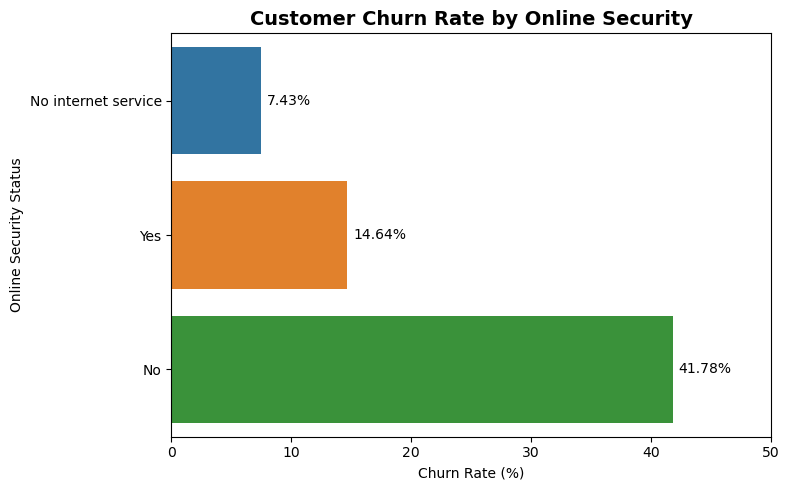

In [33]:
security_churn_rate = security_churn['Yes'].sort_values()

plt.figure(figsize=(8,5))

ax = sns.barplot(x=security_churn_rate.values, y=security_churn_rate.index)

for i, v in enumerate(security_churn_rate.values):
    ax.text(v + 0.5, i, f'{v:.2f}%', va='center')

plt.title('Customer Churn Rate by Online Security', fontsize=14, fontweight='bold')
plt.xlabel('Churn Rate (%)')
plt.ylabel('Online Security Status')
plt.xlim(0,50)

plt.tight_layout()
plt.show()

**EDA 6 : Insight**

Customers without Online Security exhibit a churn rate of 41.78%, nearly three times higher than customers who subscribe to Online Security services (14.64%).
This Suggests that customers using value-added security services are significantly more engaged and less likely to leave the company.

## EDA 7 : Tech Support vs Churn Analysis

**Does access to technical support reduce customer churn?**

In [34]:
tech_churn = pd.crosstab( df['TechSupport'], df['Churn'], normalize='index') * 100
tech_churn.round(2)

Churn,No,Yes
TechSupport,,
No,58.35,41.65
No internet service,92.57,7.43
Yes,84.80,15.20


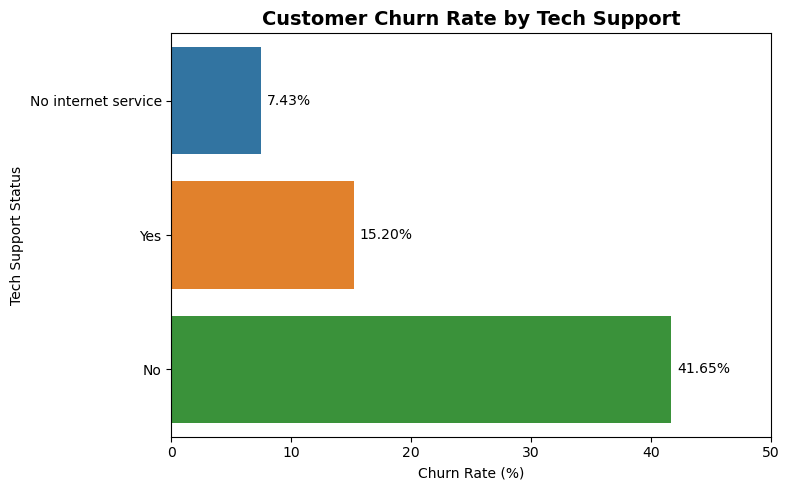

In [35]:
tech_churn_rate = tech_churn['Yes'].sort_values()

plt.figure(figsize=(8,5))

ax = sns.barplot(x=tech_churn_rate.values, y=tech_churn_rate.index)

for i, v in enumerate(tech_churn_rate.values):
    ax.text(v + 0.5, i, f'{v:.2f}%', va='center')

plt.title('Customer Churn Rate by Tech Support', fontsize=14, fontweight='bold')
plt.xlabel('Churn Rate (%)')
plt.ylabel('Tech Support Status')
plt.xlim(0,50)

plt.tight_layout()
plt.show()

**EDA 7 : Insight**

Customers without Tech Support have a churn rate of 41.65%, compared to only 15.20% for customers who subscribe to Tech Support services. This indicates that customers receiving technical assistance are significantly more likely to remain with the company.

In [37]:
df.to_csv('telecom_customers_cleaned.csv', index=False)

print("File saved successfully!")
print(df.shape)

File saved successfully!
(7032, 21)


# Machine Learning

In [ ]:
df = df.drop('customerID', axis=1)

In [ ]:
display(df.head())
print(df.columns)

In [ ]:
# Encode the target variable (Churn)

In [ ]:
df['Churn'] = df['Churn'].map({'No' : 0, 'Yes' : 1})

In [ ]:
df['Churn'].value_counts()

In [ ]:
df['Churn'].unique()

In [ ]:
# Separate Features (X) and Target (Y)

In [ ]:
X = df.drop('Churn', axis=1)
y = df['Churn']

print(X.shape)
print(y.shape)

In [ ]:
# One-Hot Encoding

In [ ]:
X = pd.get_dummies(X, drop_first=True)
print(X.shape)

In [ ]:
# Train-Test Split

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)

print("X_train : ", X_train.shape)
print("X_test : ", X_test.shape)
print("y_train : ", y_train.shape)
print("y_test : ", y_test.shape)

In [ ]:
# Feature Scaling

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)    
X_test_scaled = scaler.transform(X_test)

print(X_train_scaled.shape)
print(X_test_scaled.shape)

In [ ]:
# NOW modeling 

In [ ]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(random_state=42, max_iter=1000)
lr.fit(X_train_scaled, y_train)

In [ ]:
y_pred = lr.predict(X_test_scaled)

In [ ]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred) 
print("Accuracy : ", accuracy)

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

In [ ]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
print(cm)

In [ ]:
# visualizaiton of confusion matrix
plt.figure(figsize=(6,4))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.title('Logistic Regression Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.show()

In [ ]:
from sklearn.metrics import roc_auc_score
y_prob = lr.predict_proba(X_test_scaled)[:,1]

roc_auc = roc_auc_score(y_test, y_prob)
print("ROC-AUC Score : ", roc_auc)

In [ ]:
# Random Forest Model
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:,1]

In [ ]:
print("Accuracy : ", accuracy_score(y_test, y_pred_rf))

print(classification_report(y_test, y_pred_rf))

print(confusion_matrix(y_test, y_pred_rf))

print("ROC-AUC :", roc_auc_score(y_test, y_prob_rf))

In [ ]:
# Feature importance analysis: 
feature_importance = pd.DataFrame({'Feature': X.columns, 'Coefficient': lr.coef_[0]})
feature_importance['Abs_Coefficient'] = abs(feature_importance['Coefficient'])
feature_importance = feature_importance.sort_values(by='Abs_Coefficient', ascending=False)
feature_importance.head(15)

In [ ]:
top_features = feature_importance.head(10)

plt.figure(figsize=(10, 6))

sns.barplot(data=top_features, x='Coefficient', y='Feature')

plt.title('Top Factors Influencing Customer Churn', fontsize=14, fontweight='bold')
plt.xlabel('Coefficient')
plt.ylabel('Feature')

plt.show()

In [ ]:
# Churn Probabilities
churn_probability = lr.predict_proba(X_test_scaled)[:,1]

In [ ]:
# Prediction Dataframe
predictions = pd.DataFrame({'Actual_Churn': y_test.values,
                            'Predicted_Churn': y_pred,
                            'Churn_probability': churn_probability})
predictions.head()

In [ ]:
# Risk Segments
def risk_segment(prob):
    if prob < 0.30:
        return 'Low Risk'
    elif prob < 0.70:
        return 'Medium Risk'
    else:
        return 'High Risk'

predictions['Risk_Segment'] = predictions['Churn_probability'].apply(risk_segment)

In [ ]:
# Check segment distirbution
predictions['Risk_Segment'].value_counts()

In [ ]:
final_df = X_test.copy()
final_df['Actual_Churn'] = y_test.values
final_df['Predicted_Churn'] = y_pred
final_df['Churn_probability'] = churn_probability
final_df['Risk_Segment'] = predictions['Risk_Segment'].values

In [ ]:
final_df.head()

In [ ]:
final_df.shape

In [ ]:
final_df.columns

In [ ]:
final_df.to_csv('Customer_churn_dashboard_data.csv', index=False)

In [ ]:
import os 
os.listdir()

In [ ]:
from sklearn.model_selection import train_test_split

train_idx, test_idx = train_test_split(df.index, test_size=0.20, random_state=42, stratify=df['Churn'])
dashboard_df = df.loc[test_idx].copy()
dashboard_df['Predicted_Churn'] = y_pred
dashboard_df['Churn_probability'] = churn_probability
dashboard_df['Risk_Segment'] = predictions['Risk_Segment'].values

In [ ]:
dashboard_df.head()

In [ ]:
dashboard_df.to_csv('customer_churn_dashboard_data.csv', index=False)

In [ ]:
import os 
os.listdir()